In [40]:
import xarray as xr
import rioxarray
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.base import RegressorMixin
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
from sklego.meta import ZeroInflatedRegressor
import os
import lightgbm as lgb
import fasttreeshap
import warnings
import geopandas as gpd
from itertools import product
from scipy import stats
from joblib import Parallel, delayed
from tqdm.autonotebook import tqdm

import const

## Load data

In [2]:
westmort = xr.open_zarr("../data_working/westmort.zarr/").compute().rio.write_crs(const.PROJECTION)
westmort

<xarray.Dataset> Size: 1GB
Dimensions:       (y: 750, x: 600, time: 25)
Coordinates:
  * time          (time) datetime64[ns] 200B 1999-01-01 ... 2023-01-01
  * x             (x) float64 5kB -2.361e+06 -2.358e+06 ... -5.643e+05
  * y             (y) float64 6kB 3.179e+06 3.176e+06 ... 9.351e+05 9.321e+05
    spatial_ref   int64 8B 0
Data variables: (12/26)
    HT            (y, x) float64 4MB nan nan nan nan nan ... 17.57 17.57 nan nan
    P50           (y, x) float64 4MB nan nan nan nan ... -4.684 -4.684 nan nan
    WUE           (y, x) float64 4MB nan nan nan nan nan ... 5.657 5.657 nan nan
    def           (time, y, x) float64 90MB 0.0 0.0 0.0 ... 1.883e+03 nan
    doug_fb_ba    (y, x) float64 4MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    doug_fb_mort  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan nan
    ...            ...
    tmin          (time, y, x) float64 90MB nan nan nan nan ... 1.835 1.889 nan
    vpd           (time, y, x) float64 90MB nan nan nan nan ... 3.466 3.474 nan
    west_bb_ba    (y, x) float64 4MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    west_bb_mort  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan nan
    west_pb_ba    (y, x) float64 4MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    west_pb_mort  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan nan

## Feature engineering

We are specifically interested in out-year forecasting, so the target variable is each DCA shifted backward by one year.

In [3]:
mort_vars = list(filter(
    lambda x: x.endswith("mort"),
    list(westmort.variables.keys())
))

target_ds = westmort[mort_vars].shift(time=-1)

Note that the data changes, not the coordinates! For example

In [4]:
(
    target_ds["doug_fb_mort"].sel(time="2004-01-01").fillna(-1) == 
    westmort["doug_fb_mort"].sel(time="2005-01-01").fillna(-1)
).all()

<xarray.DataArray 'doug_fb_mort' ()> Size: 1B
array(True)
Coordinates:
    spatial_ref  int64 8B 0

This means that we can pull data from 2004 in both datasets and it will accurately represent the prediction problem.

In [5]:
# Rename variables and merge
var_rename_dict = {
    x:x.replace("mort", "target")
    for x in mort_vars
}

target_ds_rename = target_ds.rename(**var_rename_dict)

westmort_merge = xr.combine_by_coords([westmort, target_ds_rename])
westmort_merge

<xarray.Dataset> Size: 2GB
Dimensions:         (y: 750, x: 600, time: 25)
Coordinates:
  * time            (time) datetime64[ns] 200B 1999-01-01 ... 2023-01-01
  * x               (x) float64 5kB -2.361e+06 -2.358e+06 ... -5.643e+05
  * y               (y) float64 6kB 3.179e+06 3.176e+06 ... 9.351e+05 9.321e+05
    spatial_ref     int64 8B 0
Data variables: (12/34)
    HT              (y, x) float64 4MB nan nan nan nan ... 17.57 17.57 nan nan
    P50             (y, x) float64 4MB nan nan nan nan ... -4.684 -4.684 nan nan
    WUE             (y, x) float64 4MB nan nan nan nan ... 5.657 5.657 nan nan
    def             (time, y, x) float64 90MB 0.0 0.0 0.0 ... 1.883e+03 nan
    doug_fb_ba      (y, x) float64 4MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    doug_fb_mort    (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    ...              ...
    jeff_pb_target  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    mtn_pb_target   (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    pin_ips_target  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    spr_bet_target  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    west_bb_target  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan
    west_pb_target  (y, x, time) float64 90MB nan nan nan nan ... nan nan nan

Going from xarray -> dataframe will eat a lot of memory. One way to mitigate this would be to call `westmort_merge.sel(...)` to get the years/insects you want and then convert to dataframe.

In [6]:
# Prioritize selection by year since we are doing temporal CV
westmort_full_df = westmort_merge.to_dataframe(["time", "y", "x"])

## Generating data frames for training

In [7]:
westmort_full_df.columns

Index(['HT', 'P50', 'WUE', 'def', 'doug_fb_ba', 'doug_fb_mort', 'elev',
       'fir_eng_ba', 'fir_eng_mort', 'gsmax', 'heat', 'jeff_pb_ba',
       'jeff_pb_mort', 'mtn_pb_ba', 'mtn_pb_mort', 'pin_ips_ba',
       'pin_ips_mort', 'rdmax', 'spr_bet_ba', 'spr_bet_mort', 'tmin', 'vpd',
       'west_bb_ba', 'west_bb_mort', 'west_pb_ba', 'west_pb_mort',
       'spatial_ref', 'doug_fb_target', 'fir_eng_target', 'jeff_pb_target',
       'mtn_pb_target', 'pin_ips_target', 'spr_bet_target', 'west_bb_target',
       'west_pb_target'],
      dtype='object')

In [8]:
COVARIATES = {
    "hydro": ["HT", "P50", "WUE", "rdmax", "gsmax"],
    "topo": ["elev", "heat"],
    "climate": ["tmin", "vpd", "def"]
}

In [9]:
def make_data_frame(start: str, end: str, agent: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    agent_ba = f"{agent}_ba"
    agent_mort = f"{agent}_mort"
    agent_target = f"{agent}_target"
    
    cols_to_select = COVARIATES["hydro"] +\
        COVARIATES["topo"] +\
        COVARIATES["climate"] +\
        [agent_ba, agent_mort, agent_target]

    subset = westmort_full_df.loc[start:end, cols_to_select]
    train = subset.drop(end)
    train = train[train[agent_ba] > 0 & ~train[agent_target].isnull()].dropna()
    valid = subset.loc[end]
    valid = valid[valid[agent_ba] > 0 & ~valid[agent_target].isnull()].dropna()
    
    return train, valid

In [10]:
%%time
train, valid = make_data_frame("2021-01-01", "2023-01-01", "doug_fb")
del train, valid

CPU times: user 621 ms, sys: 119 ms, total: 740 ms
Wall time: 740 ms


## Model training functions

In [49]:
def make_estimator() -> lgb.LGBMRegressor:
    return lgb.LGBMRegressor(min_data_in_leaf=1000, n_estimators=500, verbosity=-1) # mitigate overfitting

def make_zif_estimator() -> ZeroInflatedRegressor:
    return ZeroInflatedRegressor(
        lgb.LGBMClassifier(min_data_in_leaf=1000, n_estimators=500, verbosity=-1),
        lgb.LGBMRegressor(min_data_in_leaf=1000, n_estimators=500, verbosity=-1)
    )

def split_xy(df: pd.DataFrame, target: str) -> tuple[np.array, np.array]:
    return (
        df.drop(columns=target).to_numpy(),
        df[target].to_numpy()
    )

def get_results(y: np.array, y_hat: np.array) -> dict[str, float]:
    mse = mean_squared_error(y, y_hat)
    nrmse = np.sqrt(mse) / np.std(y)
    r2 = r2_score(y, y_hat)
    ev = explained_variance_score(y, y_hat)
    return {
        "mse": mse,
        "nrmse": nrmse,
        "r2": r2,
        "exp_var": ev,
        "n": y.shape[0]
    }

def train_model(model: RegressorMixin, train: pd.DataFrame, valid: pd.DataFrame, target_var: str, start_year: int) -> dict:
    if train.shape[0] == 0 or valid.shape[0] == 0:
        # Subsetting resulted in no data
        return {
            "year": start_year,
            "agent": target_var
        }
    
    train_x, train_y = split_xy(train, target_var)
    valid_x, valid_y = split_xy(valid, target_var)

    model.fit(train_x, train_y)

    valid_y_hat = model.predict(valid_x)
    train_y_hat = model.predict(train_x)

    valid_results = get_results(valid_y, valid_y_hat)
    train_results = get_results(train_y, train_y_hat)

    results = {}
    results["year"] = start_year
    results["agent"] = target_var
    results["valid"] = valid_results
    results["train"] = train_results
    results["model"] = model

    return results

In [12]:
train_window_size = 4 # years
max_year = westmort_merge.time.max().data.astype('datetime64[Y]').astype(int) + 1970 - train_window_size + 1
min_year = 2001 # early years had wacky surveys, ignore them

agents = list(const.HOST_SPCODES.keys())
start_years = list(range(min_year, max_year))
param_space = list(product(agents, start_years))
print(len(param_space))

152


In [29]:
warnings.filterwarnings("ignore", message="X does not have valid feature names")

I tried several approaches to parallelizing this. On a 4-core instance there wasn't much benefit over a single-threaded approach.

In [50]:
results_gbm = []
results_zif = []

for agent, year in tqdm(param_space):
    train, valid = make_data_frame(f"{year}-01-01", f"{year+train_window_size}-01-01", agent)
    if train.shape[0] == 0 or valid.shape[0] == 0:
        continue

    gbm = make_estimator()
    zif = make_zif_estimator()

    ret_gbm = train_model(gbm, train, valid, f"{agent}_target", year)
    ret_zif = train_model(zif, train, valid, f"{agent}_target", year)
    
    results_gbm.append(ret_gbm)
    results_zif.append(ret_zif)

  0%|          | 0/152 [00:00<?, ?it/s]

In [51]:
gbm_df = pd.json_normalize(results_gbm, sep="_")
zif_df = pd.json_normalize(results_zif, sep="_")

<Axes: title={'center': 'valid_r2'}, ylabel='agent'>

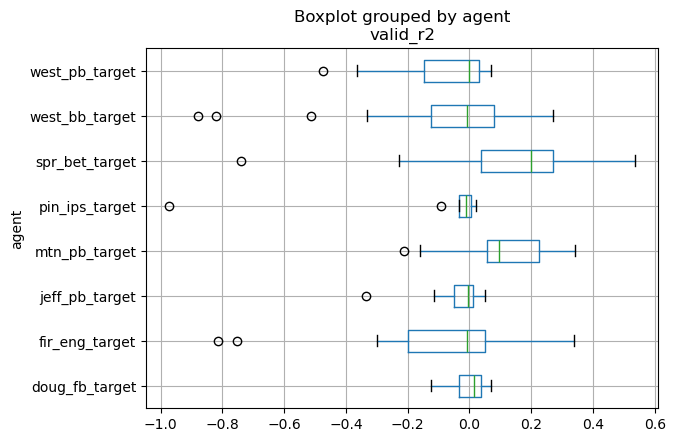

In [52]:
gbm_df[gbm_df["valid_r2"] > -1].boxplot(column="valid_r2", by="agent", vert=False)

<Axes: title={'center': 'valid_r2'}, ylabel='agent'>

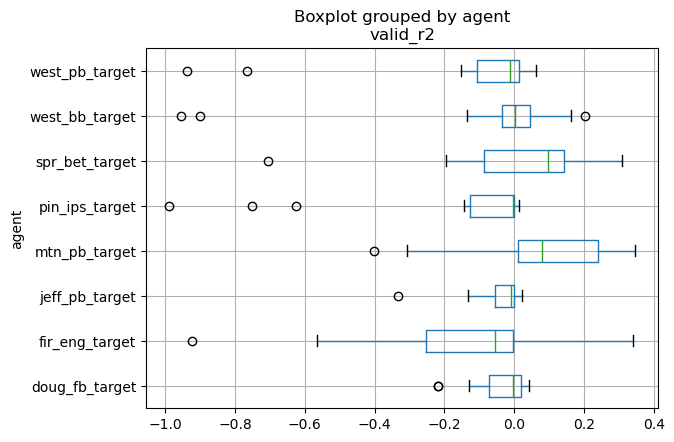

In [53]:
zif_df[zif_df["valid_r2"] > -1].boxplot(column="valid_r2", by="agent", vert=False)

In [38]:
all_cv_results.to_csv("../data_working/gbm_temporal_cv_results.csv")

In [14]:
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

In [17]:
gbm = lgb.LGBMRegressor()

param_dist = {
    "learning_rate": stats.loguniform(1e-3, 5e-1),
    "num_leaves": [2**4, 2**5, 2**6, 2**7, 2**8],
    "n_estimators": [100, 500, 1000, 1500, 2000],
    "min_data_in_leaf": [1000]
}

randcv_iter = 10

searchers = []

for agent in agents:
    print(agent)
    df, _ = make_data_frame("2001-01-01", "2022-01-01", agent)
    df = df.sample(frac=0.02)
    print(df.shape[0])
    X, y = split_xy(df, f"{agent}_target")

    rcv = RandomizedSearchCV(gbm, param_dist, n_iter=randcv_iter, scoring="r2")
    rcv.fit(X, y)
    searchers.append(rcv)

mtn_pb
30237
fir_eng
24555
pin_ips
12673
spr_bet
16468
west_pb
28771
west_bb
14876
doug_fb
27641
jeff_pb
14449


In [20]:
all_cv_results = pd.concat(
    [
        pd.DataFrame(s.cv_results_).drop(columns="params").assign(agent=agents[i])
        for i, s in enumerate(searchers)
    ]
)
all_cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_min_data_in_leaf,param_n_estimators,param_num_leaves,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,agent
0,2.833048,0.011916,0.588647,0.016470,0.019376,1000,2000,64,0.106713,0.150199,0.129207,0.161642,0.048580,0.119268,0.040014,4,mtn_pb
1,3.070021,0.059284,0.603460,0.010804,0.019215,1000,2000,64,0.107552,0.150167,0.129091,0.162827,0.048261,0.119580,0.040317,3,mtn_pb
2,2.064535,0.004401,0.395316,0.008964,0.012522,1000,1500,16,0.111040,0.159679,0.125207,0.157271,0.049138,0.120467,0.040228,1,mtn_pb
3,0.170347,0.001557,0.024185,0.000192,0.368100,1000,100,16,0.104818,0.147025,0.129612,0.163709,0.044389,0.117911,0.041615,6,mtn_pb
4,2.719624,0.012331,0.391790,0.010078,0.001172,1000,2000,16,0.095172,0.167960,0.100089,0.123890,0.045250,0.106472,0.040002,9,mtn_pb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5,0.077066,0.004013,0.007723,0.000210,0.022315,1000,100,32,-0.002779,0.006747,-0.004087,0.005722,0.013024,0.003725,0.006371,3,jeff_pb
6,1.150291,0.003910,0.172187,0.002994,0.048508,1000,2000,64,-0.119287,0.023362,-0.203885,-0.048135,0.029103,-0.063768,0.088517,9,jeff_pb
7,1.190815,0.022411,0.148494,0.002678,0.002979,1000,2000,32,-0.007920,0.012183,-0.006855,0.010670,0.025628,0.006741,0.012662,1,jeff_pb
8,0.586603,0.005913,0.077572,0.001556,0.028791,1000,1000,64,-0.045159,0.021099,-0.055985,-0.005446,0.034728,-0.010153,0.035607,6,jeff_pb


<Axes: title={'center': 'mean_test_score'}, xlabel='agent'>

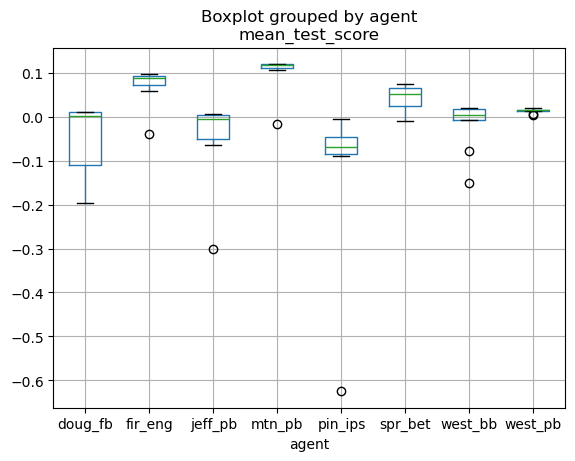

In [21]:
all_cv_results.boxplot(column="mean_test_score", by="agent")